<a href="https://colab.research.google.com/github/sajidruetcse21/Language-Invariant-Emotion-Detection-Using-Contrastive-Learning/blob/main/Base_Model(Bengali%20to%20Bengali%2C%20with%20class%20balancing%20strategy).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# CELL 1
# Install required libraries for training and evaluation
# ==========================================================

!pip install transformers scikit-learn pandas openpyxl seaborn

In [ ]:
# ==========================================================
# CELL 2
# Import all required Python libraries
# ==========================================================

import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW  # Corrected import for AdamW

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# ==========================================================
# CELL 3
# Check whether GPU is available
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# ==========================================================
# CELL 4
# Load dataset splits from CSV files
# ==========================================================

train_df = pd.read_csv("/content/train.csv")
val_df = pd.read_csv("/content/validation.csv")
test_df = pd.read_csv("/content/test.csv")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

train_df.head()

Train size: 56067
Validation size: 7929
Test size: 16101


,Label,Bengali,Banglish,English
0,anger,মিন্নী যে জঘন্য কাজ করার পরও যদি জামিন পায়।তাহ...,minni je joghonjo kaj korar poro jodi jamin pa...,"If Minni gets bail despite the heinous act, th..."
1,joy,আলহামদুলিল্লাহ অবশেষে এখান থেকে বেরিয়ে এসে পা...,alhamdulillah obosheshe ekhan theke beriye esh...,Alhamdulillah he is finally able to get out of...
2,disgust,আপনার উচিত ছিল ওদের দিয়ে গাড়ি ঠিক করানো এরপর...,apnar ucit chil oder diye gari thik korano ero...,"You should have fixed the car with them, then ..."
3,disgust,মিন্নী কে মুক্তি দেওয়া হউক &#39; তার কারণ এই খ...,minni ke mukti deoya huk &#39; tar karon ei kh...,Let Minni be released &#39; The reason is that...
4,sadness,গানটা শুনলে কোনো 😢এক অচেনা শহরে হারিয়ে যায়😢 হয়...,ganta shunle kono 😢ek ocena shohore hariye jay...,Listening to the song makes one 😢 get lost in ...


In [ ]:
# ==========================================================
# CELL 5
# Select which language column will be used for training
# and which will be used for testing
# ==========================================================

TRAIN_TEXT_COLUMN = "Bengali"
TEST_TEXT_COLUMN = "Bengali"

LABEL_COLUMN = "Label"

In [ ]:
# ==========================================================
# CELL 6
# Convert emotion labels into numerical form
# ==========================================================

label_encoder = LabelEncoder()

train_df[LABEL_COLUMN] = label_encoder.fit_transform(train_df[LABEL_COLUMN])
val_df[LABEL_COLUMN] = label_encoder.transform(val_df[LABEL_COLUMN])
test_df[LABEL_COLUMN] = label_encoder.transform(test_df[LABEL_COLUMN])

num_labels = len(label_encoder.classes_)
print("Number of emotion classes:", num_labels)
print("Classes:", label_encoder.classes_)

Number of emotion classes: 6
Classes: ['anger' 'disgust' 'fear' 'joy' 'sadness' 'surprise']


/tmp/ipykernel_4125/1687046773.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


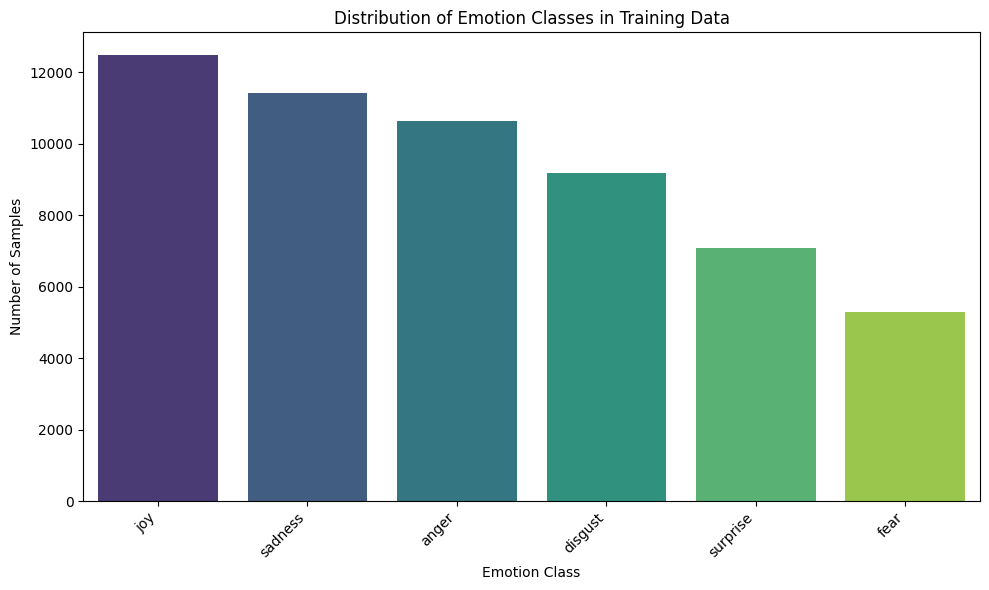

Emotion class distribution in training data:
joy         12486
sadness     11416
anger       10626
disgust      9169
surprise     7075
fear         5295
Name: count, dtype: int64


In [ ]:
# ==========================================================
# CELL 7
# Visualize the distribution of emotion classes in the training data
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of each label in the training data
label_counts = train_df[LABEL_COLUMN].value_counts()

# Map numerical labels back to original class names for better readability
class_names = label_encoder.inverse_transform(label_counts.index)
label_counts.index = class_names

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Emotion Classes in Training Data')
plt.xlabel('Emotion Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Emotion class distribution in training data:")
print(label_counts)

In [ ]:
# ==========================================================
# CELL 8
# Compute class weights for imbalanced dataset
# ==========================================================

# Ensure label_counts is indexed numerically based on label_encoder.classes_ order
# label_counts is computed in CELL 5, label_encoder.classes_ is from CELL 7
ordered_counts_series = label_counts.reindex(label_encoder.classes_)
class_counts_array = ordered_counts_series.values

total_samples = train_df.shape[0] # Total samples in training data from CELL 4
num_classes = num_labels # Number of unique classes from CELL 7

# Compute class weights using the formula: weight = total_samples / (num_classes × class_count)
raw_class_weights = total_samples / (num_classes * class_counts_array)

# Convert to tensor and move to device
class_weights = torch.tensor(raw_class_weights, dtype=torch.float).to(device)

print("Calculated Class Weights (ordered by: ", label_encoder.classes_, "):")
print(class_weights)

Calculated Class Weights (ordered by:  ['anger' 'disgust' 'fear' 'joy' 'sadness' 'surprise'] ):
tensor([0.8794, 1.0191, 1.7648, 0.7484, 0.8185, 1.3208], device='cuda:0')


In [ ]:
# ==========================================================
# CELL 9
# Load tokenizer for multilingual transformer
# ==========================================================

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

In [ ]:
# ==========================================================
# CELL 10
# Custom Dataset class for tokenizing text and loading labels
# ==========================================================

class EmotionDataset(Dataset):

    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        item = {key: val.squeeze() for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx])

        return item

In [ ]:
# ==========================================================
# CELL 11
# Create dataset objects for train, validation, and test
# ==========================================================

train_dataset = EmotionDataset(
    train_df[TRAIN_TEXT_COLUMN].tolist(),
    train_df[LABEL_COLUMN].tolist()
)

val_dataset = EmotionDataset(
    val_df[TRAIN_TEXT_COLUMN].tolist(),
    val_df[LABEL_COLUMN].tolist()
)

test_dataset = EmotionDataset(
    test_df[TEST_TEXT_COLUMN].tolist(),
    test_df[LABEL_COLUMN].tolist()
)

In [ ]:
# ==========================================================
# CELL 9 (MODIFIED FOR MULTILINGUAL TRAINING)
# Create datasets using Bangla + Banglish + English together
# ==========================================================

# # ----- TRAIN SET -----

# train_texts = (
#     train_df["Bengali"].tolist() +
#     train_df["Banglish"].tolist() +
#     train_df["English"].tolist()
# )

# train_labels = (
#     train_df[LABEL_COLUMN].tolist() +
#     train_df[LABEL_COLUMN].tolist() +
#     train_df[LABEL_COLUMN].tolist()
# )

# train_dataset = EmotionDataset(train_texts, train_labels)


# # ----- VALIDATION SET -----

# val_texts = (
#     val_df["Bengali"].tolist() +
#     val_df["Banglish"].tolist() +
#     val_df["English"].tolist()
# )

# val_labels = (
#     val_df[LABEL_COLUMN].tolist() +
#     val_df[LABEL_COLUMN].tolist() +
#     val_df[LABEL_COLUMN].tolist()
# )

# val_dataset = EmotionDataset(val_texts, val_labels)


# # ----- TEST SET -----

# test_texts = (
#     test_df["Bengali"].tolist() +
#     test_df["Banglish"].tolist() +
#     test_df["English"].tolist()
# )

# test_labels = (
#     test_df[LABEL_COLUMN].tolist() +
#     test_df[LABEL_COLUMN].tolist() +
#     test_df[LABEL_COLUMN].tolist()
# )

# test_dataset = EmotionDataset(test_texts, test_labels)

In [ ]:
# ==========================================================
# CELL 12
# Create DataLoaders for batching during training
# ==========================================================

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
# ==========================================================
# CELL 13
# Load multilingual transformer model for classification
# ==========================================================

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_labels
)

model.to(device)

In [ ]:
# ==========================================================
# CELL 14
# Initialize AdamW optimizer
# ==========================================================

optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
# ==========================================================
# CELL 15
# Function to train the model for one epoch
# ==========================================================
from tqdm.auto import tqdm
import torch.nn as nn

def train_epoch(epoch_num, class_weights):

    model.train()
    total_loss = 0

    # Initialize CrossEntropyLoss with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch_num}")

    for batch_idx, batch in enumerate(progress_bar):

        batch = {k:v.to(device) for k,v in batch.items()}

        # Forward pass
        outputs = model(**{k: v for k, v in batch.items() if k != 'labels'})
        logits = outputs.logits

        # Calculate loss using the weighted criterion
        loss = criterion(logits, batch["labels"])

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # Update progress bar with current batch loss
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(train_loader)


In [ ]:
# ==========================================================
# CELL 16
# Evaluate model performance using accuracy and macro F1
# ==========================================================

def evaluate(loader):

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for batch in loader:

            batch = {k:v.to(device) for k,v in batch.items()}

            outputs = model(**batch)

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro"
    )

    return acc, precision, recall, f1

In [ ]:
# ==========================================================
# CELL 17
# Training loop for multiple epochs
# ==========================================================

EPOCHS = 5

for epoch in range(EPOCHS):

    train_loss = train_epoch(epoch + 1, class_weights) # Pass epoch + 1 and class_weights to the function

    val_acc, val_p, val_r, val_f1 = evaluate(val_loader)

    print("Train Loss:", train_loss)
    print("Validation Accuracy:", val_acc)
    print("Validation Macro F1:", val_f1)
    print("\n")


In [ ]:
# ==========================================================
# CELL 18
# Evaluate model on the test dataset
# ==========================================================

test_acc, test_p, test_r, test_f1 = evaluate(test_loader)

print("TEST RESULTS")
print("Accuracy:", test_acc)
print("Precision:", test_p)
print("Recall:", test_r)
print("Macro F1:", test_f1)

TEST RESULTS
Accuracy: 0.6195888454133284
Precision: 0.616812024116833
Recall: 0.6337532698258128
Macro F1: 0.6112252257611176


In [ ]:
# ==========================================================
# CELL 19
# Generate and display confusion matrix for test predictions
# ==========================================================

def plot_confusion_matrix(loader):

    model.eval()

    pred_labels = []
    true_labels = []

    with torch.no_grad():

        for batch in loader:

            batch = {k:v.to(device) for k,v in batch.items()}

            outputs = model(**batch)

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            pred_labels.extend(predictions.cpu().numpy())
            true_labels.extend(batch["labels"].cpu().numpy())

    cm = confusion_matrix(true_labels, pred_labels)

    class_names = label_encoder.classes_

    plt.figure(figsize=(10,8)) # Increased figure size for better resolution

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues", # Added cmap for better visualization
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    # Save high resolution image
    plt.savefig("confusion_matrix.png", dpi=600, bbox_inches="tight")
    plt.show()

    print("Confusion matrix saved as confusion_matrix.png")

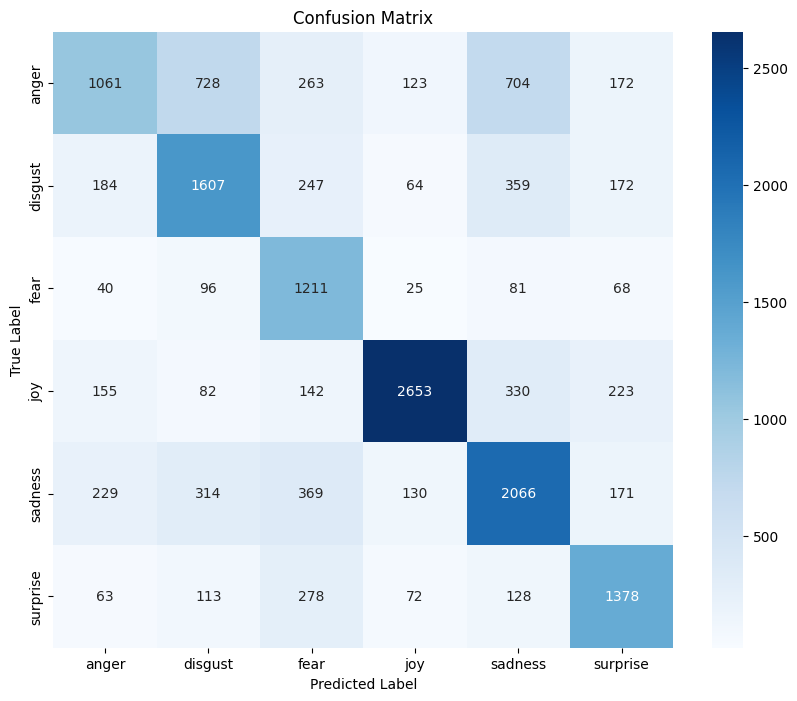

Confusion matrix saved as confusion_matrix.png


In [ ]:
# ==========================================================
# CELL 20
# Call function to visualize confusion matrix
# ==========================================================

plot_confusion_matrix(test_loader)